# 第25章: 因子分析・グラフィカルモデル

## 学習目標
- 因子分析モデルを理解する
- 抽出法（主因子法、最尤法）を適用できる
- 因子回転を実行し解釈できる
- グラフィカルモデルの基礎を理解する

## 📋 学習メタ情報

### 推定学習時間
**110〜140分**

### 難易度
**★★★★☆** (5段階中4)

---

## 🎯 なぜこの章を学ぶのか？

この章の内容は、実務での統計的データ分析に直結する重要なトピックです。理論と実践の両面から理解を深めましょう。

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.linalg import svd
import seaborn as sns
from sklearn.decomposition import FactorAnalysis
from sklearn.preprocessing import StandardScaler

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
np.random.seed(42)

## 25.1 因子分析モデル

### モデル
$$\mathbf{x} = \boldsymbol{\mu} + \mathbf{\Lambda} \mathbf{f} + \boldsymbol{\epsilon}$$

- $\mathbf{x}$: 観測変数 (p次元)
- $\mathbf{f}$: 共通因子 (m次元, m < p)
- $\boldsymbol{\Lambda}$: 因子負荷量行列 (p×m)
- $\boldsymbol{\epsilon}$: 独自因子

### 仮定
- $E[\mathbf{f}] = \mathbf{0}$, $\text{Cov}(\mathbf{f}) = \mathbf{I}$
- $E[\boldsymbol{\epsilon}] = \mathbf{0}$, $\text{Cov}(\boldsymbol{\epsilon}) = \mathbf{\Psi}$ (対角行列)
- $\text{Cov}(\mathbf{f}, \boldsymbol{\epsilon}) = \mathbf{0}$

### 共分散構造
$$\boldsymbol{\Sigma} = \mathbf{\Lambda}\mathbf{\Lambda}^T + \mathbf{\Psi}$$

In [2]:
# 因子分析モデルに基づくデータ生成
np.random.seed(123)

n = 300  # Sample size
p = 6    # Number of observed variables
m = 2    # Number of factors

# True factor loadings
Lambda_true = np.array([
    [0.9, 0.1],
    [0.8, 0.2],
    [0.7, 0.3],
    [0.2, 0.8],
    [0.1, 0.9],
    [0.3, 0.7]
])

# Unique variances
psi_true = np.array([0.2, 0.3, 0.4, 0.3, 0.2, 0.4])

# Generate factors
F = np.random.randn(n, m)

# Generate errors
epsilon = np.random.randn(n, p) * np.sqrt(psi_true)

# Generate observed data
X = F @ Lambda_true.T + epsilon

print("因子分析モデル")
print("="*60)
print(f"\nサンプルサイズ: n = {n}")
print(f"観測変数数: p = {p}")
print(f"因子数: m = {m}")

print("\n真の因子負荷量行列:")
print(Lambda_true)

print("\n真の独自性:")
print(psi_true)

因子分析モデル

サンプルサイズ: n = 300
観測変数数: p = 6
因子数: m = 2

真の因子負荷量行列:
[[0.9 0.1]
 [0.8 0.2]
 [0.7 0.3]
 [0.2 0.8]
 [0.1 0.9]
 [0.3 0.7]]

真の独自性:
[0.2 0.3 0.4 0.3 0.2 0.4]


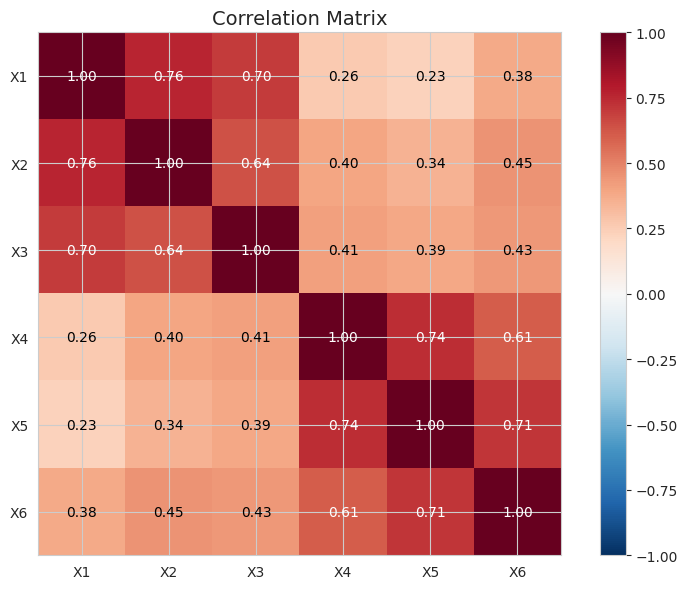


観察: X1, X2, X3が高い相関、X4, X5, X6が高い相関
→ 2つの潜在因子の存在を示唆


In [3]:
# Visualize correlation matrix
corr_matrix = np.corrcoef(X.T)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(p))
ax.set_yticks(range(p))
ax.set_xticklabels([f'X{i+1}' for i in range(p)])
ax.set_yticklabels([f'X{i+1}' for i in range(p)])
ax.set_title('Correlation Matrix', fontsize=14)

# Add text
for i in range(p):
    for j in range(p):
        text = ax.text(j, i, f'{corr_matrix[i, j]:.2f}',
                       ha='center', va='center',
                       color='white' if abs(corr_matrix[i, j]) > 0.5 else 'black')

plt.colorbar(im)
plt.tight_layout()
plt.show()

print("\n観察: X1, X2, X3が高い相関、X4, X5, X6が高い相関")
print("→ 2つの潜在因子の存在を示唆")

## 25.2 抽出法

### 主因子法
相関行列から独自性の推定値を引いた行列を固有値分解

$$\mathbf{R} - \hat{\mathbf{\Psi}} = \hat{\mathbf{\Lambda}}\hat{\mathbf{\Lambda}}^T$$

### 最尤法
多変量正規分布を仮定し、尤度を最大化

$$L(\mathbf{\Lambda}, \mathbf{\Psi}) = -\frac{n}{2}\left[\log|\boldsymbol{\Sigma}| + \text{tr}(\mathbf{S}\boldsymbol{\Sigma}^{-1})\right]$$

In [4]:
# 主因子法の実装
def principal_factor(R, m, max_iter=100, tol=1e-6):
    """Principal factor method for factor analysis."""
    p = R.shape[0]
    
    # Initial communality estimate (squared multiple correlation)
    R_inv = np.linalg.inv(R)
    h2 = 1 - 1 / np.diag(R_inv)
    
    for iteration in range(max_iter):
        # Reduced correlation matrix
        R_reduced = R.copy()
        np.fill_diagonal(R_reduced, h2)
        
        # Eigenvalue decomposition
        eigenvalues, eigenvectors = np.linalg.eigh(R_reduced)
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]
        
        # Factor loadings
        Lambda = eigenvectors[:, :m] * np.sqrt(np.maximum(eigenvalues[:m], 0))
        
        # Update communalities
        h2_new = np.sum(Lambda**2, axis=1)
        
        # Check convergence
        if np.max(np.abs(h2_new - h2)) < tol:
            break
        
        h2 = h2_new
    
    # Uniqueness
    psi = 1 - h2
    
    return Lambda, psi, eigenvalues

# Apply principal factor method
R = np.corrcoef(X.T)
Lambda_pf, psi_pf, eigenvalues = principal_factor(R, m)

print("主因子法")
print("="*60)
print("\n推定因子負荷量:")
print(Lambda_pf.round(3))
print("\n推定独自性:")
print(psi_pf.round(3))

主因子法

推定因子負荷量:
[[-0.736 -0.591]
 [-0.749 -0.356]
 [-0.723 -0.276]
 [-0.695  0.389]
 [-0.75   0.569]
 [-0.725  0.281]]

推定独自性:
[0.109 0.313 0.401 0.365 0.113 0.396]


In [5]:
# 最尤法（sklearn）
X_std = StandardScaler().fit_transform(X)
fa_ml = FactorAnalysis(n_components=m, rotation=None, random_state=42)
fa_ml.fit(X_std)

Lambda_ml = fa_ml.components_.T
psi_ml = fa_ml.noise_variance_

print("\n最尤法 (sklearn)")
print("="*60)
print("\n推定因子負荷量:")
print(Lambda_ml.round(3))
print("\n推定独自性:")
print(psi_ml.round(3))


最尤法 (sklearn)

推定因子負荷量:
[[ 0.754 -0.552]
 [ 0.76  -0.338]
 [ 0.736 -0.255]
 [ 0.677  0.428]
 [ 0.725  0.584]
 [ 0.722  0.312]]

推定独自性:
[0.128 0.307 0.393 0.358 0.134 0.382]


## 25.3 因子回転

### 目的
因子負荷量の解釈を容易にするため、因子軸を回転

### 直交回転
- **バリマックス (Varimax)**: 因子負荷量の分散を最大化
- **クォーティマックス (Quartimax)**: 各変数の因子負荷量の簡潔化

### 斜交回転
- **プロマックス (Promax)**: 因子間の相関を許容
- **オブリミン (Oblimin)**: 一般的な斜交回転

In [6]:
# バリマックス回転の実装
def varimax_rotation(Lambda, max_iter=100, tol=1e-6):
    """Varimax rotation of factor loadings."""
    p, m = Lambda.shape
    T = np.eye(m)  # Rotation matrix
    Lambda_rot = Lambda.copy()
    
    for iteration in range(max_iter):
        for i in range(m - 1):
            for j in range(i + 1, m):
                # Extract columns
                x = Lambda_rot[:, i]
                y = Lambda_rot[:, j]
                
                # Calculate rotation angle
                u = x**2 - y**2
                v = 2 * x * y
                
                A = np.sum(u)
                B = np.sum(v)
                C = np.sum(u**2 - v**2)
                D = np.sum(2 * u * v)
                
                num = D - 2 * A * B / p
                denom = C - (A**2 - B**2) / p
                
                phi = 0.25 * np.arctan2(num, denom)
                
                # Apply rotation
                cos_phi = np.cos(phi)
                sin_phi = np.sin(phi)
                
                Lambda_rot[:, i] = x * cos_phi + y * sin_phi
                Lambda_rot[:, j] = -x * sin_phi + y * cos_phi
    
    return Lambda_rot

# Apply varimax rotation
Lambda_rotated = varimax_rotation(Lambda_pf)

print("バリマックス回転")
print("="*60)
print("\n回転前の因子負荷量:")
print(Lambda_pf.round(3))
print("\n回転後の因子負荷量:")
print(Lambda_rotated.round(3))

バリマックス回転

回転前の因子負荷量:
[[-0.736 -0.591]
 [-0.749 -0.356]
 [-0.723 -0.276]
 [-0.695  0.389]
 [-0.75   0.569]
 [-0.725  0.281]]

回転後の因子負荷量:
[[-0.965  0.088]
 [-0.819  0.167]
 [-0.746  0.182]
 [-0.283  0.38 ]
 [-0.207  0.457]
 [-0.378  0.357]]


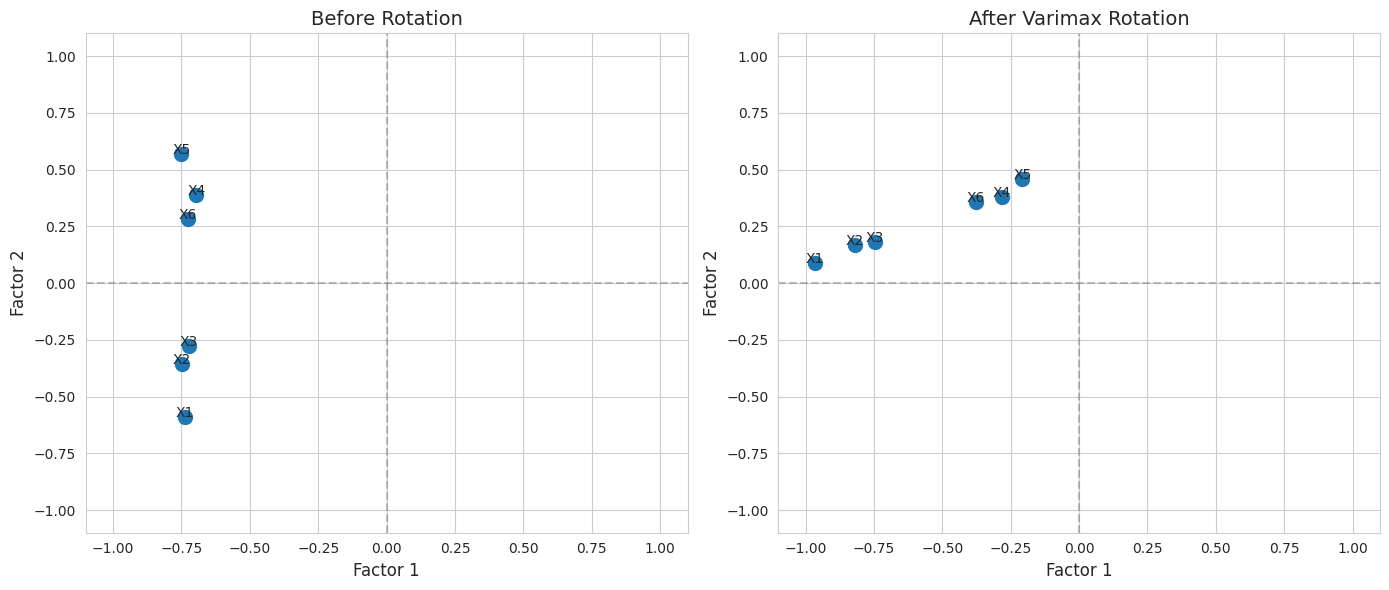


回転後の解釈:
Factor 1: X1, X2, X3 が高負荷 → 第1潜在因子
Factor 2: X4, X5, X6 が高負荷 → 第2潜在因子


In [7]:
# Visualize factor loadings before and after rotation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

variables = [f'X{i+1}' for i in range(p)]

# Before rotation
axes[0].scatter(Lambda_pf[:, 0], Lambda_pf[:, 1], s=100)
for i, var in enumerate(variables):
    axes[0].annotate(var, (Lambda_pf[i, 0], Lambda_pf[i, 1]), 
                     fontsize=10, ha='center')
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Factor 1', fontsize=12)
axes[0].set_ylabel('Factor 2', fontsize=12)
axes[0].set_title('Before Rotation', fontsize=14)
axes[0].set_xlim(-1.1, 1.1)
axes[0].set_ylim(-1.1, 1.1)

# After rotation
axes[1].scatter(Lambda_rotated[:, 0], Lambda_rotated[:, 1], s=100)
for i, var in enumerate(variables):
    axes[1].annotate(var, (Lambda_rotated[i, 0], Lambda_rotated[i, 1]), 
                     fontsize=10, ha='center')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Factor 1', fontsize=12)
axes[1].set_ylabel('Factor 2', fontsize=12)
axes[1].set_title('After Varimax Rotation', fontsize=14)
axes[1].set_xlim(-1.1, 1.1)
axes[1].set_ylim(-1.1, 1.1)

plt.tight_layout()
plt.show()

print("\n回転後の解釈:")
print("Factor 1: X1, X2, X3 が高負荷 → 第1潜在因子")
print("Factor 2: X4, X5, X6 が高負荷 → 第2潜在因子")

## 25.4 因子数の決定

### カイザー基準
固有値 > 1 の因子を採用

### スクリープロット
固有値の急激な減少点（肘）で決定

### 平行分析
ランダムデータの固有値と比較

因子数の決定


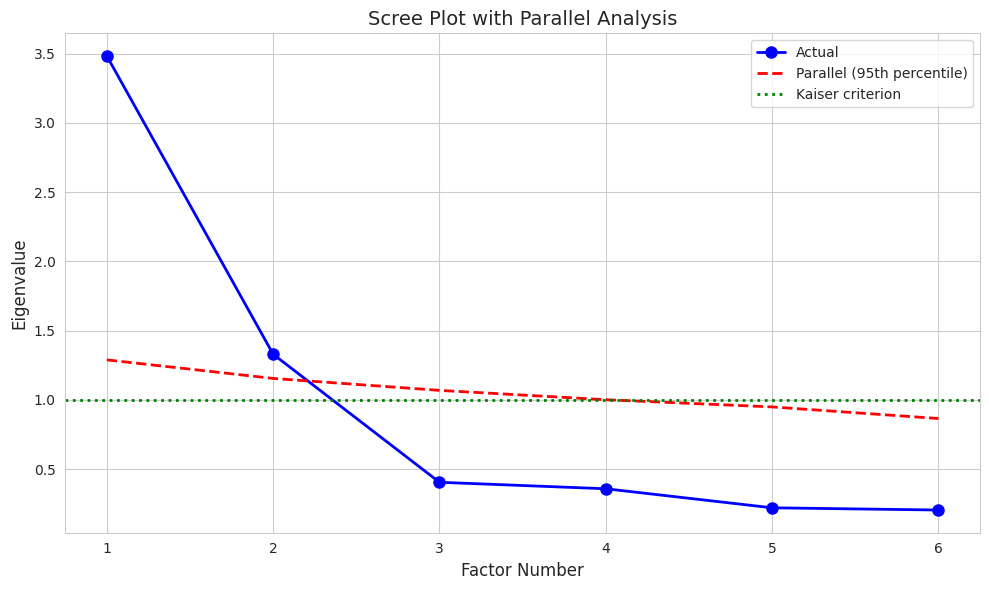


カイザー基準: 2 因子
平行分析: 2 因子


In [8]:
# 因子数の決定
print("因子数の決定")
print("="*60)

# Eigenvalues from correlation matrix
eigenvalues_corr, _ = np.linalg.eigh(R)
eigenvalues_corr = np.sort(eigenvalues_corr)[::-1]

# Parallel analysis
n_sim = 100
random_eigenvalues = np.zeros((n_sim, p))

for i in range(n_sim):
    random_data = np.random.randn(n, p)
    R_random = np.corrcoef(random_data.T)
    eig_random, _ = np.linalg.eigh(R_random)
    random_eigenvalues[i] = np.sort(eig_random)[::-1]

parallel_threshold = np.percentile(random_eigenvalues, 95, axis=0)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, p+1), eigenvalues_corr, 'bo-', linewidth=2, markersize=8, label='Actual')
ax.plot(range(1, p+1), parallel_threshold, 'r--', linewidth=2, label='Parallel (95th percentile)')
ax.axhline(1, color='green', linestyle=':', linewidth=2, label='Kaiser criterion')
ax.set_xlabel('Factor Number', fontsize=12)
ax.set_ylabel('Eigenvalue', fontsize=12)
ax.set_title('Scree Plot with Parallel Analysis', fontsize=14)
ax.legend()
ax.set_xticks(range(1, p+1))
plt.tight_layout()
plt.show()

# Determine number of factors
n_kaiser = np.sum(eigenvalues_corr > 1)
n_parallel = np.sum(eigenvalues_corr > parallel_threshold)

print(f"\nカイザー基準: {n_kaiser} 因子")
print(f"平行分析: {n_parallel} 因子")

## 25.5 共通性と独自性

### 共通性 (Communality)
$$h_i^2 = \sum_{j=1}^{m} \lambda_{ij}^2$$

共通因子によって説明される分散の割合

### 独自性 (Uniqueness)
$$\psi_i = 1 - h_i^2$$

独自因子による分散

In [9]:
# 共通性と独自性
print("共通性と独自性")
print("="*60)

# Calculate communalities
communalities = np.sum(Lambda_rotated**2, axis=1)
uniqueness = 1 - communalities

print(f"\n{'変数':>8} {'共通性':>10} {'独自性':>10}")
print("-"*30)
for i in range(p):
    print(f"{'X'+str(i+1):>8} {communalities[i]:>10.3f} {uniqueness[i]:>10.3f}")

print(f"\n平均共通性: {np.mean(communalities):.3f}")

共通性と独自性

      変数        共通性        独自性
------------------------------
      X1      0.940      0.060
      X2      0.699      0.301
      X3      0.590      0.410
      X4      0.225      0.775
      X5      0.251      0.749
      X6      0.271      0.729

平均共通性: 0.496


## 25.6 グラフィカルモデル入門

### 概要
変数間の条件付き独立性をグラフで表現

### 種類
1. **無向グラフィカルモデル**: マルコフランダム場
2. **有向グラフィカルモデル**: ベイジアンネットワーク

### 条件付き独立性
他の変数を条件付けたときの独立性
$$X \perp Y | Z$$

グラフィカルモデル入門

偏相関行列 (他の変数を制御した相関):


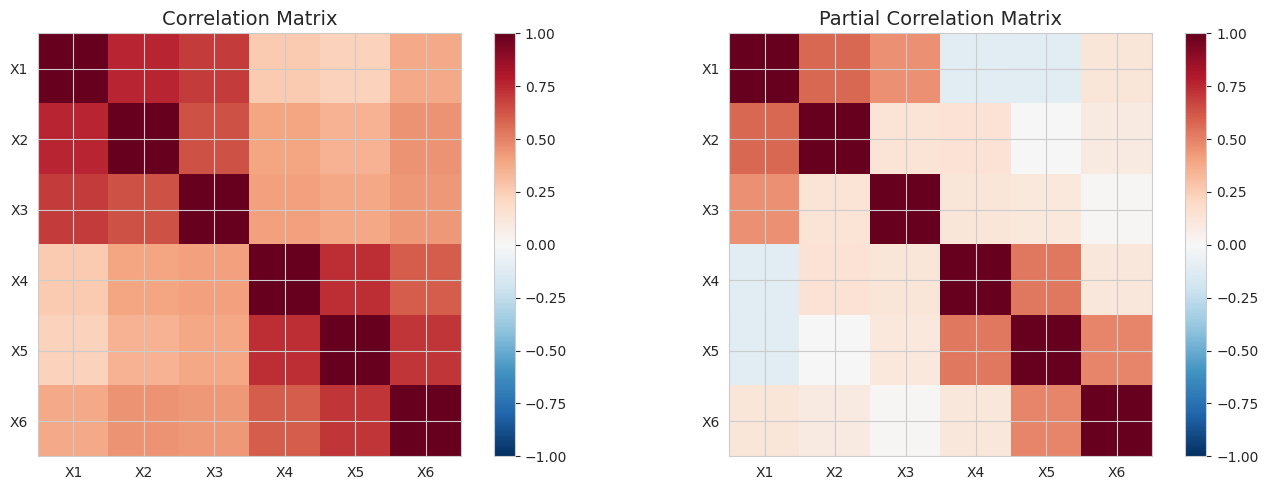


偏相関行列の解釈:
・0に近い値 → 他の変数を制御すると条件付き独立
・グラフィカルモデルではエッジなしで表現


In [10]:
# グラフィカルモデルの可視化（偏相関行列を用いた例）
print("グラフィカルモデル入門")
print("="*60)

# Calculate partial correlation matrix
precision = np.linalg.inv(R)
partial_corr = np.zeros_like(precision)

for i in range(p):
    for j in range(p):
        if i == j:
            partial_corr[i, j] = 1
        else:
            partial_corr[i, j] = -precision[i, j] / np.sqrt(precision[i, i] * precision[j, j])

print("\n偏相関行列 (他の変数を制御した相関):")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation matrix
im1 = axes[0].imshow(R, cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_title('Correlation Matrix', fontsize=14)
axes[0].set_xticks(range(p))
axes[0].set_yticks(range(p))
axes[0].set_xticklabels([f'X{i+1}' for i in range(p)])
axes[0].set_yticklabels([f'X{i+1}' for i in range(p)])
plt.colorbar(im1, ax=axes[0])

# Partial correlation matrix
im2 = axes[1].imshow(partial_corr, cmap='RdBu_r', vmin=-1, vmax=1)
axes[1].set_title('Partial Correlation Matrix', fontsize=14)
axes[1].set_xticks(range(p))
axes[1].set_yticks(range(p))
axes[1].set_xticklabels([f'X{i+1}' for i in range(p)])
axes[1].set_yticklabels([f'X{i+1}' for i in range(p)])
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

print("\n偏相関行列の解釈:")
print("・0に近い値 → 他の変数を制御すると条件付き独立")
print("・グラフィカルモデルではエッジなしで表現")

## 25.7 練習問題

### 問題1
因子分析とPCAの違いを説明せよ。

### 問題2
バリマックス回転の目的と効果を説明せよ。

### 問題3
共通性が0.3以下の変数があった場合、どのように解釈すべきか。

In [11]:
# 問題1の解答
print("問題1: 因子分析とPCAの違い")
print("="*60)

print("""
【目的の違い】
PCA: データの分散を最大限説明する合成変数を作成
FA:  観測変数の背後にある潜在因子を推定

【モデルの違い】
PCA: X = TW' (単なる変換、誤差項なし)
FA:  X = ΛF + ε (誤差項あり)

【分散の扱い】
PCA: 全分散を説明
FA:  共通分散のみを説明（独自性は別）

【回転】
PCA: 通常回転しない（直交基底）
FA:  解釈のため回転が一般的

【使い分け】
PCA: 次元削減、データ圧縮
FA:  潜在構造の探索、尺度開発
""")

問題1: 因子分析とPCAの違い

【目的の違い】
PCA: データの分散を最大限説明する合成変数を作成
FA:  観測変数の背後にある潜在因子を推定

【モデルの違い】
PCA: X = TW' (単なる変換、誤差項なし)
FA:  X = ΛF + ε (誤差項あり)

【分散の扱い】
PCA: 全分散を説明
FA:  共通分散のみを説明（独自性は別）

【回転】
PCA: 通常回転しない（直交基底）
FA:  解釈のため回転が一般的

【使い分け】
PCA: 次元削減、データ圧縮
FA:  潜在構造の探索、尺度開発



In [12]:
# 問題2の解答
print("問題2: バリマックス回転")
print("="*60)

print("""
【目的】
因子負荷量の単純構造を実現し、解釈を容易にする

【方法】
各因子の負荷量の分散を最大化
→ 各変数は少数の因子にのみ高い負荷を持つ

【効果】
1. 各因子を少数の変数で特徴付けられる
2. 各変数が主に1つの因子に関連
3. 因子の命名・解釈が容易になる

【特徴】
・直交回転（因子間は無相関を維持）
・共通性は変化しない
・最も広く使われる回転法
""")

問題2: バリマックス回転

【目的】
因子負荷量の単純構造を実現し、解釈を容易にする

【方法】
各因子の負荷量の分散を最大化
→ 各変数は少数の因子にのみ高い負荷を持つ

【効果】
1. 各因子を少数の変数で特徴付けられる
2. 各変数が主に1つの因子に関連
3. 因子の命名・解釈が容易になる

【特徴】
・直交回転（因子間は無相関を維持）
・共通性は変化しない
・最も広く使われる回転法



In [13]:
# 問題3の解答
print("問題3: 低い共通性の解釈")
print("="*60)

print("""
共通性が0.3以下 = 分散の30%以下しか共通因子で説明されない

【考えられる原因】
1. その変数は抽出した因子と関連が弱い
2. 独自の因子を持っている（測定されていない因子）
3. 測定誤差が大きい
4. 因子数が不十分

【対処法】
1. 因子数を増やして再分析
2. その変数を除外して再分析
3. 変数の質を検討（測定方法の改善）
4. 別の因子構造を検討

【注意点】
・低共通性=必ずしも問題ではない
・理論的に重要な変数は残すことも
・確認的因子分析で検証
""")

問題3: 低い共通性の解釈

共通性が0.3以下 = 分散の30%以下しか共通因子で説明されない

【考えられる原因】
1. その変数は抽出した因子と関連が弱い
2. 独自の因子を持っている（測定されていない因子）
3. 測定誤差が大きい
4. 因子数が不十分

【対処法】
1. 因子数を増やして再分析
2. その変数を除外して再分析
3. 変数の質を検討（測定方法の改善）
4. 別の因子構造を検討

【注意点】
・低共通性=必ずしも問題ではない
・理論的に重要な変数は残すことも
・確認的因子分析で検証



## ⚠️ よくある間違いと解決策

統計分析では、手法の前提条件を確認せずに適用してしまうことがよくあります。必ず前提を確認し、適切な手法を選択しましょう。

---

## 📝 理解度チェック

この章で学んだ内容を振り返り、重要な概念を自分の言葉で説明できるか確認しましょう。

---

## 📚 まとめ

お疲れ様でした！この章で学んだ手法は、実際のデータ分析で頻繁に使われます。実データで試して理解を深めましょう。

---